In [ ]:
# ============================
# RICE GRAIN CLASSIFICATION USING MACHINE LEARNING
# ============================
import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
# -----------------------------
# Dataset Path
# -----------------------------
dataset_path = "Rice_Image_Dataset"

In [ ]:
# -----------------------------
# Read Images
# -----------------------------
images = []
labels = []
IMG_SIZE = 64
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        for image_name in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_name)
            image = cv2.imread(image_path)
            if image is None:
                continue
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # Flatten image
            feature = image.flatten()
            images.append(feature)
            labels.append(folder)

In [6]:
print(labels)

['Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio', 'Arborio'

In [7]:
# -----------------------------
# Convert to Array
# -----------------------------
X = np.array(images)
y = np.array(labels)

print("Dataset Shape :", X.shape)

Dataset Shape : (75000, 12288)


In [8]:
# -----------------------------
# Encode Labels
# -----------------------------
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("\nClasses:")
for i, cls in enumerate(encoder.classes_):
    print(i, ":", cls)


Classes:
0 : Arborio
1 : Basmati
2 : Ipsala
3 : Jasmine
4 : Karacadag


In [10]:
# -----------------------------
# Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
# -----------------------------
# Machine Learning Model
# -----------------------------
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
# -----------------------------
# Prediction
# -----------------------------
y_pred = model.predict(X_test)

In [15]:
# -----------------------------
# Accuracy
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
print(accuracy*100,'%')

print("\nAccuracy : {:.2f}%".format(accuracy*100))

99.42666666666666 %

Accuracy : 99.43%


In [14]:
# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))


Classification Report

              precision    recall  f1-score   support

     Arborio       0.99      0.99      0.99      3000
     Basmati       0.99      0.99      0.99      3000
      Ipsala       1.00      1.00      1.00      3000
     Jasmine       0.99      0.99      0.99      3000
   Karacadag       1.00      0.99      0.99      3000

    accuracy                           0.99     15000
   macro avg       0.99      0.99      0.99     15000
weighted avg       0.99      0.99      0.99     15000



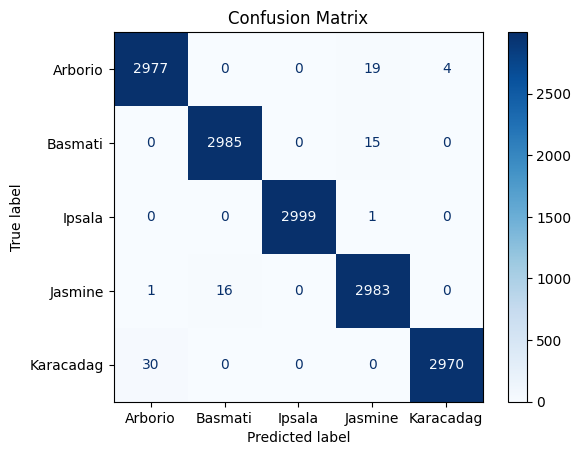

In [16]:
# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [17]:
# -----------------------------
# Save Model
# -----------------------------
joblib.dump(model, "rice_ml_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")

print("\nModel Saved Successfully!")


Model Saved Successfully!


Predicted Rice Variety : Karacadag


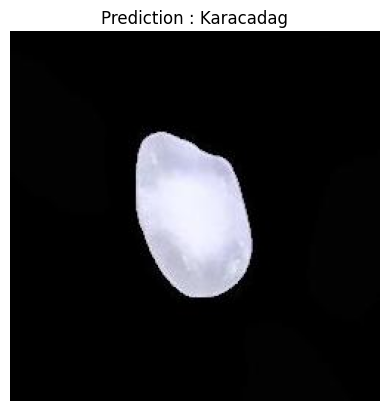

In [43]:
# Image path
image_path =r"C:\Users\kisho\Desktop\NASSCOM\batch_3_year3\rice_ml\Rice_Image_Dataset\pred\1.jpg"
image = cv2.imread(image_path)
# Display Original Image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
# Preprocessing (Same as Training)
img = cv2.resize(image, (64, 64))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
feature = img.flatten().reshape(1, -1)
# Prediction
pred = model.predict(feature)[0]
class_name = encoder.inverse_transform([pred])[0]
print("Predicted Rice Variety :", class_name)
plt.title(f"Prediction : {class_name}")
plt.show()

In [37]:
a=np.array([1,2,3,4,5,6])
print(a)
print(a.reshape(2,-1))

[1 2 3 4 5 6]
[[1 2 3]
 [4 5 6]]


In [23]:
# -----------------------------
# Read Images
# -----------------------------
images = []
IMG_SIZE = 64
for img in os.listdir(pred):
    print(img)

basmati (17).jpg
basmati (19).jpg
basmati (24).jpg
basmati (29).jpg
basmati (36).jpg
Ipsala (14).jpg
Ipsala (18).jpg
Ipsala (26).jpg
